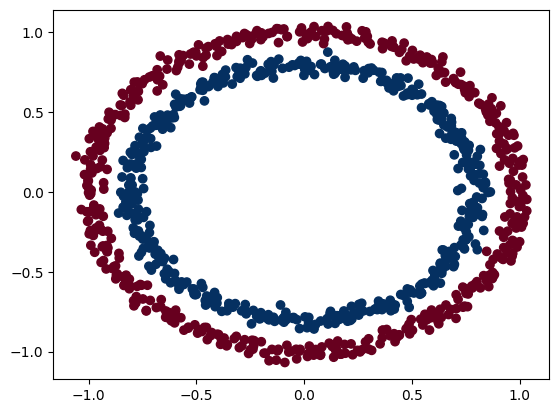

In [ ]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

x, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdBu);

In [ ]:
x , y

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
        1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 1, 0, 1, 

In [ ]:
import torch
from torch import nn

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2)
len(x_train) , len(x_test)

(800, 200)

In [ ]:
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2 , out_features=16)
    self.layer2 = nn.Linear(in_features= 16 , out_features=16)
    self.layer3 = nn.Linear(in_features=16 , out_features=16)
    self.layer4 = nn.Linear(in_features=16 , out_features=1)
    self.Relu = nn.ReLU()

  def forward(self , x):
    return self.layer4(self.Relu(self.layer3(self.Relu(self.layer2(self.Relu(self.layer1(x)))))))

model_3 = CircleModelV2()

In [ ]:
#self up loss an dpop

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),lr=0.1)
def accuracy(y_true , y_preds):
  correct = torch.eq(y_true ,y_preds).sum().item()
  acc = (correct/len(y_preds))*100
  return acc


In [ ]:
import torch
from torch import nn

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
model_3.to(device)

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Convert data to tensors and move to device
x_train_tensor = torch.from_numpy(x_train).float().to(device)
y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(dim=1).to(device)
x_test_tensor = torch.from_numpy(x_test).float().to(device)
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(dim=1).to(device)

epochs = 10000
for epoch in range(epochs):
  model_3.train()
  # 1. Forward pass
  y_logits = model_3(x_train_tensor)
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate loss
  loss = loss_fn(y_logits, y_train_tensor)
  train_accuracy = accuracy(y_true = y_train_tensor, y_preds = y_pred)


  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(x_test_tensor)
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test_tensor)
    test_accuracy = accuracy(y_true = y_test_tensor, y_preds=test_pred)

  if epoch%100 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Train Acc: {train_accuracy:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

Epoch: 0 | Loss: 0.5905 | Train Acc: 77.12% | Test Loss: 0.6076 | Test Acc: 75.00%
Epoch: 100 | Loss: 0.4383 | Train Acc: 98.50% | Test Loss: 0.4565 | Test Acc: 97.50%
Epoch: 200 | Loss: 0.4023 | Train Acc: 77.25% | Test Loss: 0.4457 | Test Acc: 69.00%
Epoch: 300 | Loss: 0.3975 | Train Acc: 74.00% | Test Loss: 0.5267 | Test Acc: 62.00%
Epoch: 400 | Loss: 0.0579 | Train Acc: 100.00% | Test Loss: 0.0642 | Test Acc: 100.00%
Epoch: 500 | Loss: 0.0299 | Train Acc: 100.00% | Test Loss: 0.0330 | Test Acc: 100.00%
Epoch: 600 | Loss: 0.0191 | Train Acc: 100.00% | Test Loss: 0.0211 | Test Acc: 100.00%
Epoch: 700 | Loss: 0.0136 | Train Acc: 100.00% | Test Loss: 0.0153 | Test Acc: 100.00%
Epoch: 800 | Loss: 0.0105 | Train Acc: 100.00% | Test Loss: 0.0119 | Test Acc: 100.00%
Epoch: 900 | Loss: 0.0085 | Train Acc: 100.00% | Test Loss: 0.0098 | Test Acc: 100.00%
Epoch: 1000 | Loss: 0.0071 | Train Acc: 100.00% | Test Loss: 0.0083 | Test Acc: 100.00%
Epoch: 1100 | Loss: 0.0061 | Train Acc: 100.00% | Te

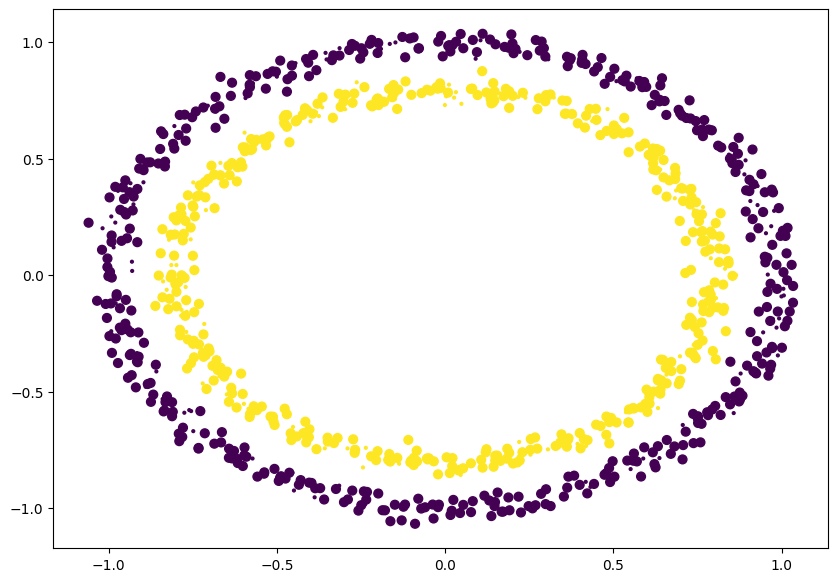

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(train_data = x_train , train_labels = y_train , test_data=x_test , test_labels = y_test , plot_predictions = None):
  plt.figure(figsize=(10, 7))
  plt.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, s=40)
  plt.scatter(test_data[:, 0], test_data[:, 1], c=test_labels, s=4)

plot_predictions()

In [ ]:
#evaluation t he model
model_3.eval
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(x_test_tensor)))

y_preds[:10] , y_test[:10]

(tensor([[0.],
         [1.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.]], device='cuda:0'),
 array([0, 1, 1, 0, 1, 0, 1, 0, 0, 0]))

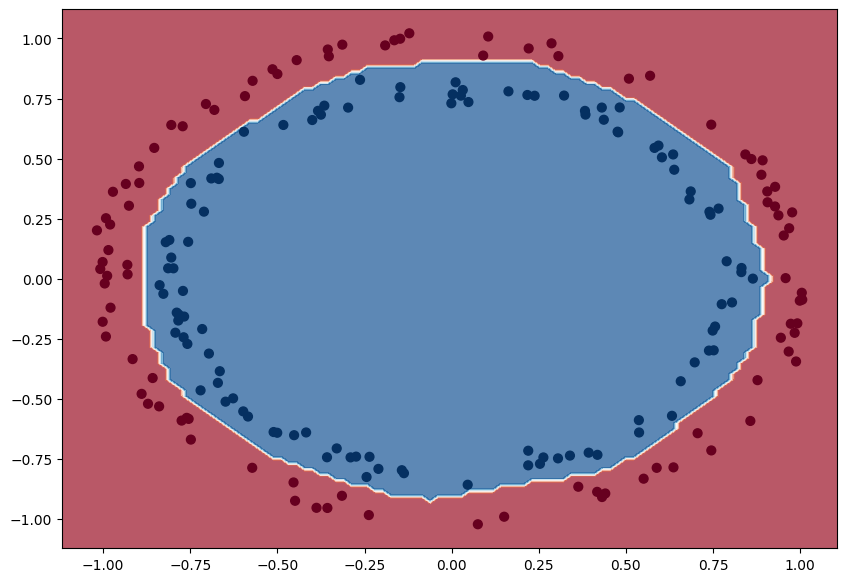

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model, X, y):
    # Put everything to CPU (or GPU if available and desired)
    X = X.cpu().numpy()
    y = y.cpu().numpy()

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Make predictions for the meshgrid
    model.eval()
    with torch.inference_mode():
        y_logits = model(torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float().to(next(model.parameters()).device))
    y_pred = torch.round(torch.sigmoid(y_logits)).cpu().numpy().reshape(xx.shape)

    # Plot decision boundaries
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.figure(figsize=(10, 7))
plot_decision_boundary(model_3, x_test_tensor, y_test_tensor)

In [ ]:
model_3.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.8372, -0.6129],
                      [-0.6167,  0.1787],
                      [-0.2671, -1.4182],
                      [ 0.4995, -1.9656],
                      [ 0.8814,  1.7583],
                      [ 0.7298, -0.5989],
                      [ 1.0886,  0.3254],
                      [ 0.7892,  0.2505],
                      [ 1.0559, -1.1150],
                      [-0.1591,  0.1928],
                      [-0.2716,  1.8871],
                      [-0.6803,  0.0073],
                      [ 0.1321, -0.1878],
                      [ 1.7434,  0.1916],
                      [-2.0631, -0.1909],
                      [-0.6797,  0.0428]], device='cuda:0')),
             ('layer1.bias',
              tensor([-0.1428, -0.7014, -0.4176, -0.4330, -0.2189,  1.1414, -0.4045,  1.0073,
                      -0.3121, -0.5969, -0.6239,  0.7366, -0.4625, -0.5783, -0.3165,  0.6528],
                     device='cuda:0')),
             ('laye